## Exploratory Data Analysis 

This notebook provides dataset structure and quality inspection for each dataset, analyzing data types, missing values and duplicates rows.

In [5]:
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
import seaborn as sns
import collections
import warnings

# Configure pandas display settings
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 1000)

### 1. Inspection Function

The `inspect_dataset(df, dataset_name)` function inspects data types, missing values, unique values, sample entries, and duplicate rows for a given dataset.

In [16]:
def inspect_dataset(df, dataset_name="Dataset"):
    """
    Inspection of data types, missing values, unique counts, sample entries, and duplicate rows.
    """
    print(f"Inspection Report: {dataset_name}")
    print(f"Dataset Shape: {df.shape[0]:,} rows × {df.shape[1]:,} columns\n")
    
    # Column-level summary
    summary_df = pd.DataFrame({
        'Data Type': df.dtypes,
        'Missing Values': df.isnull().sum(),
        'Missing (%)': (df.isnull().sum() / len(df) * 100).round(2) if len(df) > 0 else 0,
        'Unique Values': df.nunique(),
        'Sample Value': [df[col].dropna().iloc[0] if not df[col].dropna().empty else np.nan for col in df.columns]
    })
    
    # Duplicate rows count
    dup_count = df.duplicated().sum()
    dup_pct = (dup_count / len(df) * 100) if len(df) > 0 else 0
    print(f"\nDuplicate Rows: {dup_count:,}")

    
    df.info()
    return summary_df

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns


def univariate_analysis(df, categorical_cols, numerical_cols=None, datetime_cols=None):
  """Performs univariate analysis with summary stats,

  value counts, and distribution plots.
  """
  # 1. Numerical & ID Summary Statistics
  if numerical_cols:
    print("=== Numerical Feature Summary ===")
    display(df[numerical_cols].describe())
    print("\n" + "=" * 50 + "\n")

  # 2. Categorical Distribution & Plots
  print("=== Categorical Feature Distributions ===")
  for col in categorical_cols:
    print(f"\nTop 10 Value Counts for: **{col}**")
    top_counts = df[col].value_counts().head(10)
    display(top_counts)

    # Plotting the distribution of top categories
    plt.figure(figsize=(10, 4))
    sns.countplot(
        data=df, y=col, order=df[col].value_counts().index[:10], palette="Blues_r"
    )
    plt.title(f"Top 10 Distribution - {col}", fontsize=12, fontweight="bold")
    plt.xlabel("Count", fontsize=10)
    plt.ylabel(col, fontsize=10)
    plt.show()
    print("-" * 50)


# Run the analysis on your dataset
categorical_cols = ["Bank Name", "Entity Name"]
numerical_cols = ["Bank ID"]


### 2. Importing Datasets

Load each dataset explicitly into its own variable.

In [7]:
# Download the dataset only when files used by this notebook are missing.
from pathlib import Path

DATASET_HANDLE = "ealtman2019/ibm-transactions-for-anti-money-laundering-aml"
DATA_DIR = Path("data")
REQUIRED_DATA_FILES = [
    "HI-Small_accounts.csv",
    "HI-Medium_accounts.csv",
    "LI-Small_accounts.csv",
    "LI-Medium_accounts.csv",
    "HI-Small_Trans.csv",
    "HI-Medium_Trans.csv",
    "LI-Small_Trans.csv",
    "LI-Medium_Trans.csv",
    "HI-Medium_Patterns.txt",
    "HI-Small_Patterns.txt",
    "LI-Medium_Patterns.txt",
    "LI-Small_Patterns.txt",
]

missing_files = [name for name in REQUIRED_DATA_FILES if not (DATA_DIR / name).is_file()]
if missing_files:
    import kagglehub
    import shutil

    DATA_DIR.mkdir(parents=True, exist_ok=True)
    downloaded_dir = Path(kagglehub.dataset_download(DATASET_HANDLE))
    for name in missing_files:
        downloaded_file = downloaded_dir / name
        if not downloaded_file.is_file():
            raise FileNotFoundError(
                f"Kaggle dataset download did not contain expected file: {downloaded_file}"
            )
        shutil.copy2(downloaded_file, DATA_DIR / name)
    missing_files = [name for name in REQUIRED_DATA_FILES if not (DATA_DIR / name).is_file()]
    if missing_files:
        raise FileNotFoundError(
            f"Kaggle download did not provide expected files in {DATA_DIR}: {missing_files}"
        )

100%|██████████| 7.61G/7.61G [30:54<00:00, 4.41MB/s]  

Extracting files...


## 3. Transactions Dataset Analysis

### 3.1 Small Transactions Dataset Analysis

In [11]:
# Load the HI-Small and LI-Small transaction datasets.
hi_small_trans = pd.read_csv(DATA_DIR / "HI-Small_Trans.csv")
li_small_trans = pd.read_csv(DATA_DIR / "LI-Small_Trans.csv")

In [12]:
# Both transaction datasets have the same schema.
transaction_categorical_cols = [
    "Account",
    "Account.1",
    "Receiving Currency",
    "Payment Currency",
    "Payment Format",
    "Is Laundering",  # Binary target
]

transaction_numerical_cols = [
    "From Bank",
    "To Bank",
    "Amount Received",
    "Amount Paid",
]

# Timestamp is temporal, so keep it separate from categorical and numerical features.
transaction_datetime_cols = ["Timestamp"]

In [13]:
display(inspect_dataset(hi_small_trans, dataset_name="HI-Small Transactions"))

Inspection Report: HI-Small Transactions
Dataset Shape: 5,078,345 rows × 11 columns


Duplicate Rows: 9
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5078345 entries, 0 to 5078344
Data columns (total 11 columns):
 #   Column              Dtype  
---  ------              -----  
 0   Timestamp           object 
 1   From Bank           int64  
 2   Account             object 
 3   To Bank             int64  
 4   Account.1           object 
 5   Amount Received     float64
 6   Receiving Currency  object 
 7   Amount Paid         float64
 8   Payment Currency    object 
 9   Payment Format      object 
 10  Is Laundering       int64  
dtypes: float64(2), int64(3), object(6)
memory usage: 426.2+ MB


,Data Type,Missing Values,Missing (%),Unique Values,Sample Value
Timestamp,object,0,0.0,15018,2022/09/01 00:20
From Bank,int64,0,0.0,30470,10
Account,object,0,0.0,496995,8000EBD30
To Bank,int64,0,0.0,15811,10
Account.1,object,0,0.0,420636,8000EBD30
Amount Received,float64,0,0.0,915161,3697.34
Receiving Currency,object,0,0.0,15,US Dollar
Amount Paid,float64,0,0.0,923873,3697.34
Payment Currency,object,0,0.0,15,US Dollar
Payment Format,object,0,0.0,7,Reinvestment


In [14]:
hi_small_trans["Timestamp"] = pd.to_datetime(hi_small_trans["Timestamp"])
li_small_trans["Timestamp"] = pd.to_datetime(li_small_trans["Timestamp"])

=== Numerical Feature Summary ===


,From Bank,To Bank,Amount Received,Amount Paid
count,5.078345e+06,5.078345e+06,5.078345e+06,5.078345e+06
mean,4.573057e+04,6.574456e+04,5.988726e+06,4.509273e+06
std,8.176562e+04,8.409299e+04,1.037183e+09,8.697728e+08
min,1.000000e+00,1.000000e+00,1.000000e-06,1.000000e-06
25%,1.190000e+02,4.259000e+03,1.833700e+02,1.844800e+02
50%,9.679000e+03,2.156800e+04,1.411010e+03,1.414540e+03
75%,2.862800e+04,1.223320e+05,1.234627e+04,1.229784e+04
max,3.563030e+05,3.562940e+05,1.046302e+12,1.046302e+12




=== Categorical Feature Distributions ===

Top 10 Value Counts for: **Account**


Account
100428660    168672
1004286A8    103018
100428978     20497
1004286F0     18663
100428780     17264
1004289C0     16794
100428810     16426
1004287C8     14174
100428738     13756
100428A51     13073
Name: count, dtype: int64

C:\Users\almad\AppData\Local\Temp\ipykernel_32244\969024602.py:51: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


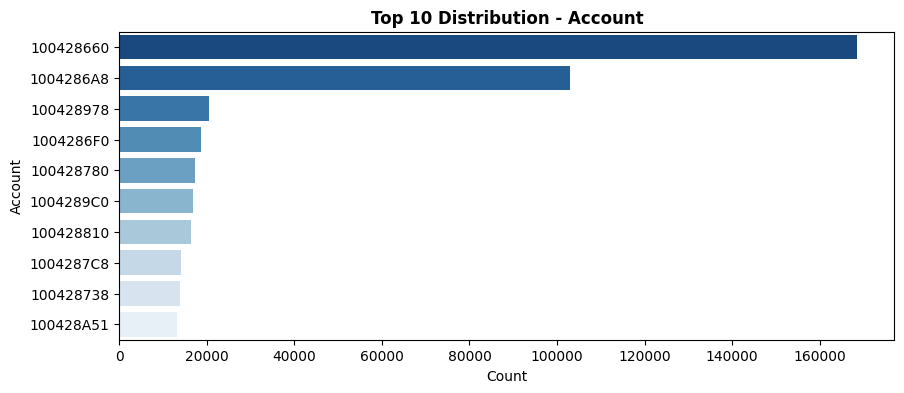

--------------------------------------------------

Top 10 Value Counts for: **Account.1**


Account.1
100428660    1084
1004286A8     653
80F47A310     159
100428978     150
8018859B0     144
1004289C0     132
100428780     117
100428810     114
80F0EF460     109
1004286F0     108
Name: count, dtype: int64

C:\Users\almad\AppData\Local\Temp\ipykernel_32244\969024602.py:51: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


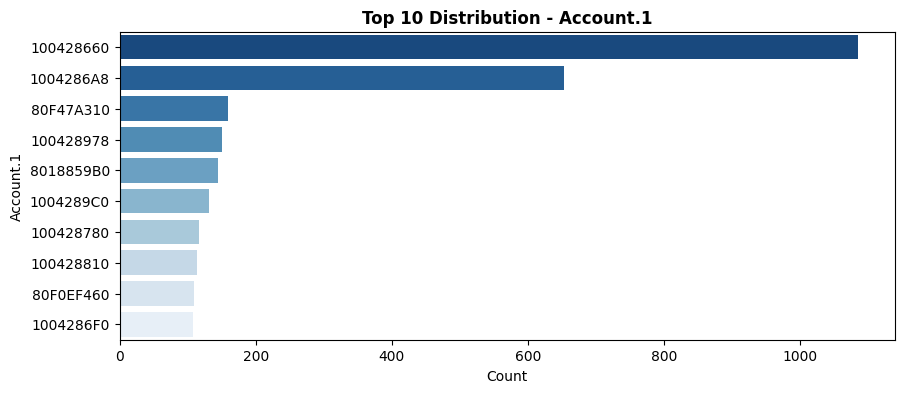

--------------------------------------------------

Top 10 Value Counts for: **Receiving Currency**


Receiving Currency
US Dollar      1879341
Euro           1172017
Swiss Franc     237884
Yuan            206551
Shekel          194988
Rupee           192065
UK Pound        181255
Ruble           157361
Yen             156319
Bitcoin         148151
Name: count, dtype: int64

C:\Users\almad\AppData\Local\Temp\ipykernel_32244\969024602.py:51: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


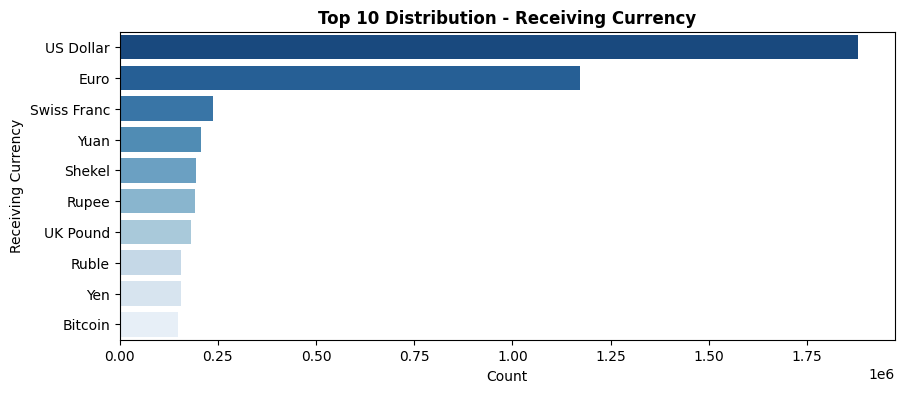

--------------------------------------------------

Top 10 Value Counts for: **Payment Currency**


Payment Currency
US Dollar      1895172
Euro           1168297
Swiss Franc     234860
Yuan            213752
Shekel          192184
Rupee           190202
UK Pound        180738
Yen             155209
Ruble           155178
Bitcoin         146066
Name: count, dtype: int64

C:\Users\almad\AppData\Local\Temp\ipykernel_32244\969024602.py:51: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


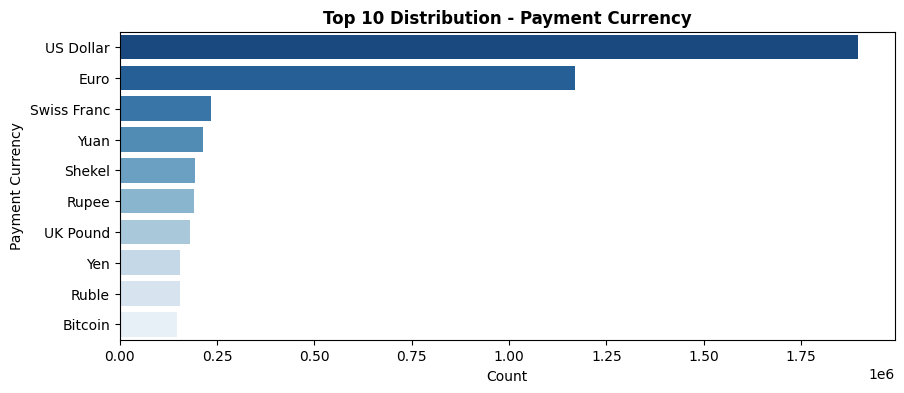

--------------------------------------------------

Top 10 Value Counts for: **Payment Format**


Payment Format
Cheque          1864331
Credit Card     1323324
ACH              600797
Cash             490891
Reinvestment     481056
Wire             171855
Bitcoin          146091
Name: count, dtype: int64

C:\Users\almad\AppData\Local\Temp\ipykernel_32244\969024602.py:51: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


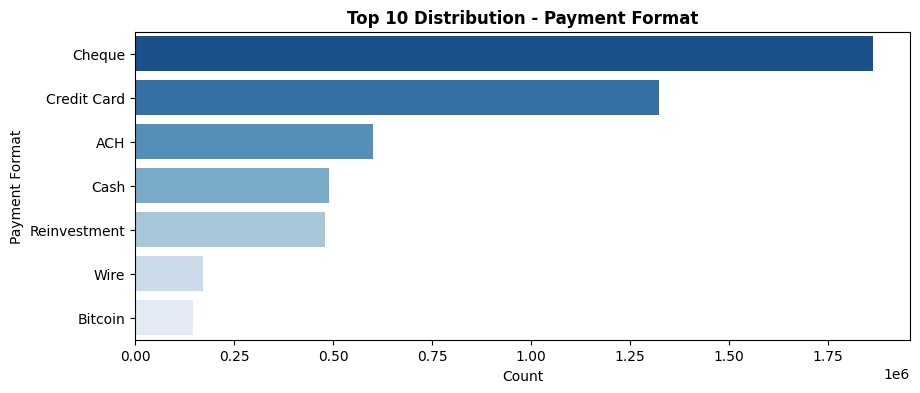

--------------------------------------------------

Top 10 Value Counts for: **Is Laundering**


Is Laundering
0    5073168
1       5177
Name: count, dtype: int64

C:\Users\almad\AppData\Local\Temp\ipykernel_32244\969024602.py:51: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


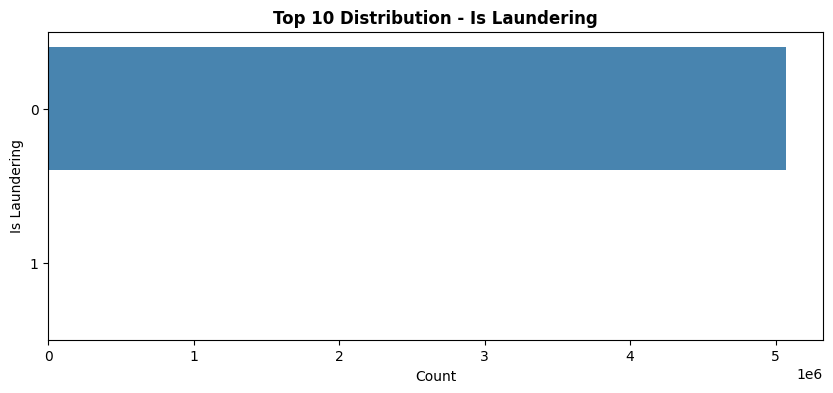

--------------------------------------------------


In [17]:
univariate_analysis(
    hi_small_trans,
    categorical_cols=transaction_categorical_cols,
    numerical_cols=transaction_numerical_cols,
    datetime_cols=transaction_datetime_cols
)

In [ ]:
display(inspect_dataset(li_small_trans, dataset_name="LI-Small Transactions"))

Inspection Report: LI-Small Transactions
Dataset Shape: 6,924,049 rows × 11 columns


Duplicate Rows: 8
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6924049 entries, 0 to 6924048
Data columns (total 11 columns):
 #   Column              Dtype  
---  ------              -----  
 0   Timestamp           object 
 1   From Bank           int64  
 2   Account             object 
 3   To Bank             int64  
 4   Account.1           object 
 5   Amount Received     float64
 6   Receiving Currency  object 
 7   Amount Paid         float64
 8   Payment Currency    object 
 9   Payment Format      object 
 10  Is Laundering       int64  
dtypes: float64(2), int64(3), object(6)
memory usage: 581.1+ MB


,Data Type,Missing Values,Missing (%),Unique Values,Sample Value
Timestamp,object,0,0.0,14533,2022/09/01 00:08
From Bank,int64,0,0.0,41814,11
Account,object,0,0.0,681281,8000ECA90
To Bank,int64,0,0.0,21588,11
Account.1,object,0,0.0,576176,8000ECA90
Amount Received,float64,0,0.0,1194921,3195403.0
Receiving Currency,object,0,0.0,15,US Dollar
Amount Paid,float64,0,0.0,1204309,3195403.0
Payment Currency,object,0,0.0,15,US Dollar
Payment Format,object,0,0.0,7,Reinvestment


=== Numerical Feature Summary ===


,From Bank,To Bank,Amount Received,Amount Paid
count,6.924049e+06,6.924049e+06,6.924049e+06,6.924049e+06
mean,5.938718e+04,8.441702e+04,6.324067e+06,4.676036e+06
std,9.051700e+04,9.064562e+04,2.105371e+09,1.544099e+09
min,0.000000e+00,0.000000e+00,1.000000e-06,1.000000e-06
25%,2.190000e+02,1.125500e+04,1.742100e+02,1.753800e+02
50%,1.419500e+04,2.964000e+04,1.397620e+03,1.399440e+03
75%,1.106820e+05,1.480400e+05,1.229633e+04,1.222687e+04
max,3.769670e+05,3.769670e+05,3.644854e+12,3.644854e+12




=== Categorical Feature Distributions ===

Top 10 Value Counts for: **Account**


Account
10042B660    222037
10042B6A8    138777
10042B6F0     42385
10042B780     30802
10042BA51     28932
10042BA08     22417
10042B930     19445
10042B8A0     19254
10042B738     18213
10042B9C0     16266
Name: count, dtype: int64

C:\Users\almad\AppData\Local\Temp\ipykernel_32244\969024602.py:51: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


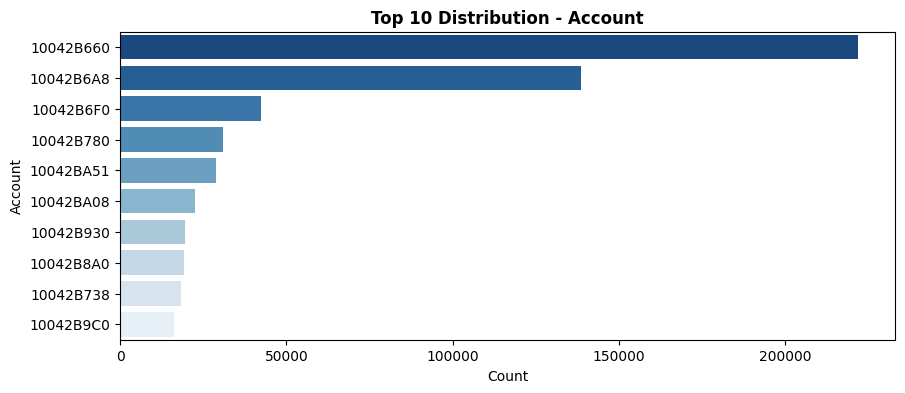

--------------------------------------------------

Top 10 Value Counts for: **Account.1**


Account.1
10042B660    1553
10042B6A8     951
10042B6F0     345
10042B780     223
10042BA08     170
10042B8A0     160
81632FCA0     140
10042B738     135
803878810     131
10042B930     131
Name: count, dtype: int64

C:\Users\almad\AppData\Local\Temp\ipykernel_32244\969024602.py:51: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


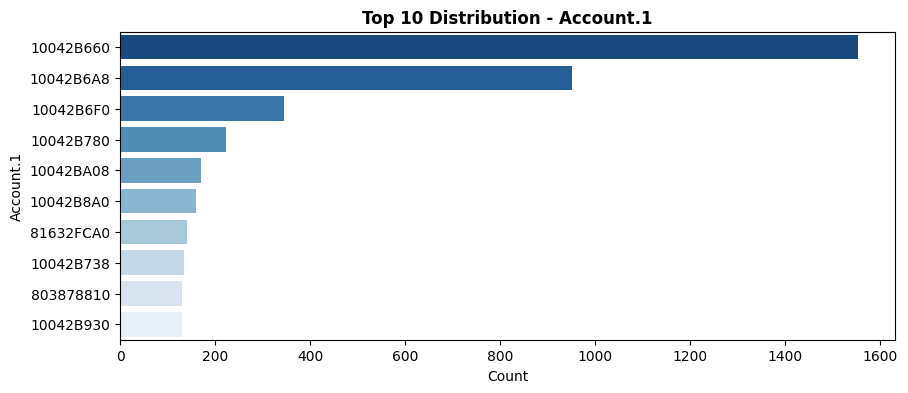

--------------------------------------------------

Top 10 Value Counts for: **Receiving Currency**


Receiving Currency
US Dollar            2537242
Euro                 1596407
Yuan                  474978
Rupee                 344237
Bitcoin               313196
Saudi Riyal           261882
Australian Dollar     213905
Yen                   211631
Brazil Real           202717
Canadian Dollar       177966
Name: count, dtype: int64

C:\Users\almad\AppData\Local\Temp\ipykernel_32244\969024602.py:51: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


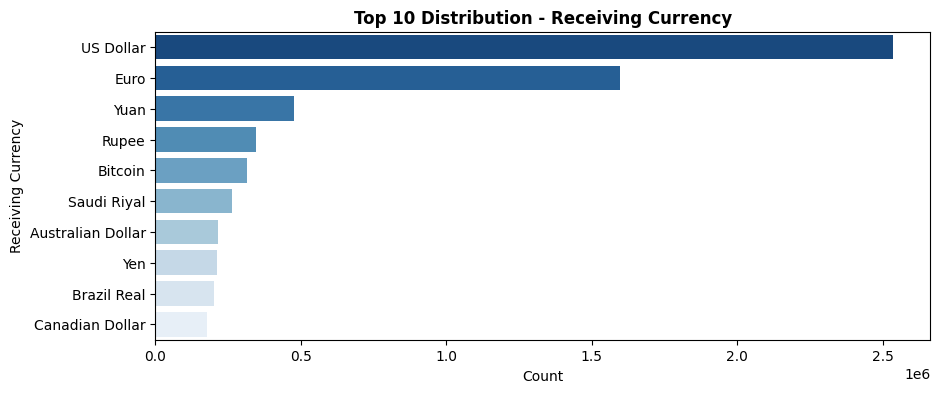

--------------------------------------------------

Top 10 Value Counts for: **Payment Currency**


Payment Currency
US Dollar            2553887
Euro                 1595859
Yuan                  483603
Rupee                 340641
Bitcoin               309240
Saudi Riyal           257948
Australian Dollar     211155
Yen                   210125
Brazil Real           199840
Canadian Dollar       176069
Name: count, dtype: int64

C:\Users\almad\AppData\Local\Temp\ipykernel_32244\969024602.py:51: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


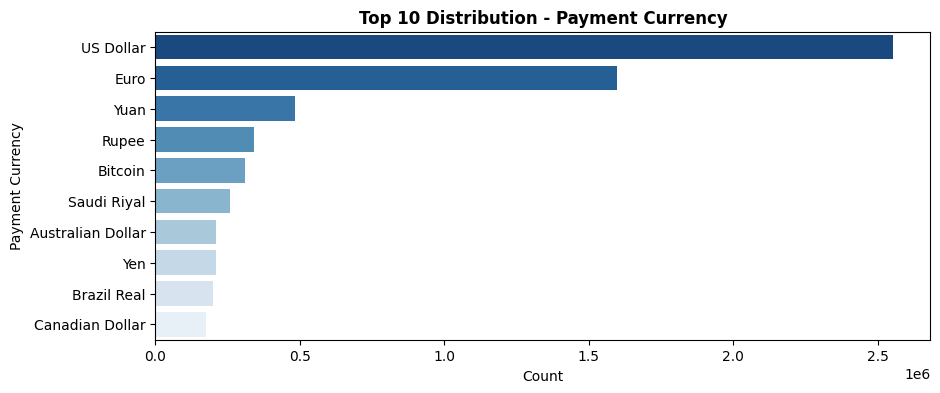

--------------------------------------------------

Top 10 Value Counts for: **Payment Format**


Payment Format
Cheque          2503158
Credit Card     1780389
ACH              796581
Cash             655688
Reinvestment     650458
Bitcoin          309208
Wire             228567
Name: count, dtype: int64

C:\Users\almad\AppData\Local\Temp\ipykernel_32244\969024602.py:51: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


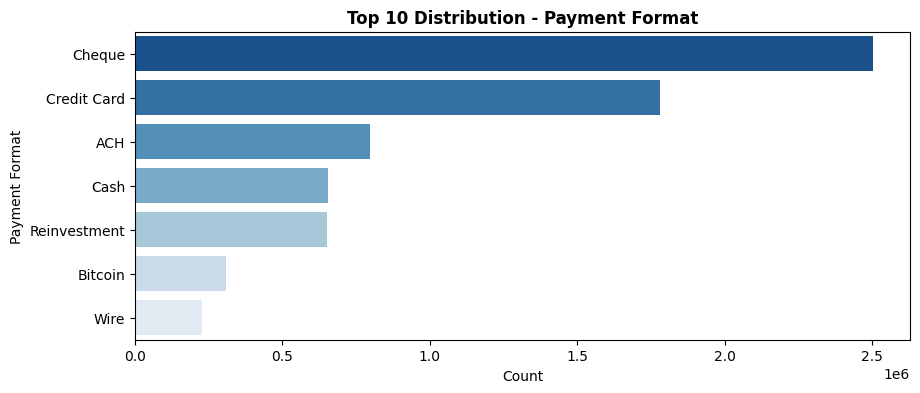

--------------------------------------------------

Top 10 Value Counts for: **Is Laundering**


Is Laundering
0    6920484
1       3565
Name: count, dtype: int64

C:\Users\almad\AppData\Local\Temp\ipykernel_32244\969024602.py:51: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


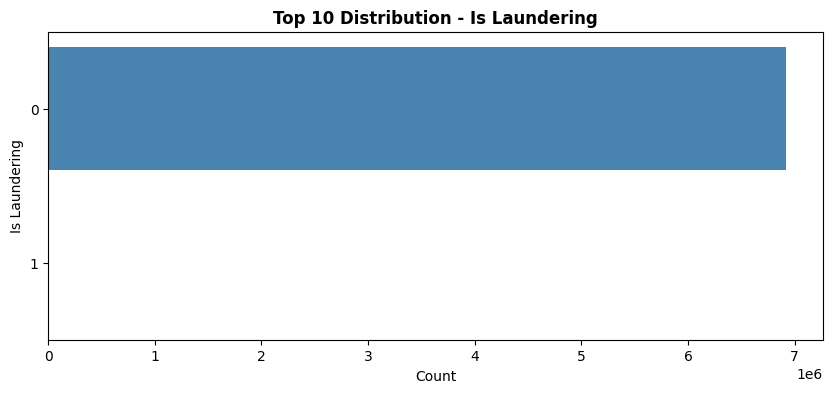

--------------------------------------------------


In [18]:
univariate_analysis(
    li_small_trans,
    categorical_cols=transaction_categorical_cols,
    numerical_cols=transaction_numerical_cols,
    datetime_cols=transaction_datetime_cols,
)

### 3.2 Medium Transactions Dataset Analysis

In [20]:
import gc

# Free any previously loaded full-size medium transaction dataframes.
for var_name in ("hi_medium_trans", "li_medium_trans"):
    if var_name in globals():
        del globals()[var_name]
gc.collect()

hi_medium_trans = pd.read_csv(DATA_DIR / "HI-Medium_Trans.csv", nrows=5_000_000)
li_medium_trans = pd.read_csv(DATA_DIR / "LI-Medium_Trans.csv", nrows=5_000_000)

print("HI-Medium:", hi_medium_trans.shape)
print("LI-Medium:", li_medium_trans.shape)

HI-Medium: (5000000, 11)
LI-Medium: (5000000, 11)


Inspection Report: HI-Medium Transactions
Dataset Shape: 5,000,000 rows × 11 columns


Duplicate Rows: 0
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000000 entries, 0 to 4999999
Data columns (total 11 columns):
 #   Column              Dtype  
---  ------              -----  
 0   Timestamp           object 
 1   From Bank           int64  
 2   Account             object 
 3   To Bank             int64  
 4   Account.1           object 
 5   Amount Received     float64
 6   Receiving Currency  object 
 7   Amount Paid         float64
 8   Payment Currency    object 
 9   Payment Format      object 
 10  Is Laundering       int64  
dtypes: float64(2), int64(3), object(6)
memory usage: 419.6+ MB


,Data Type,Missing Values,Missing (%),Unique Values,Sample Value
Timestamp,object,0,0.0,3028,2022/09/01 00:17
From Bank,int64,0,0.0,98734,20
Account,object,0,0.0,1728956,800104D70
To Bank,int64,0,0.0,60977,20
Account.1,object,0,0.0,1646983,800104D70
Amount Received,float64,0,0.0,2215872,6794.63
Receiving Currency,object,0,0.0,15,US Dollar
Amount Paid,float64,0,0.0,2232015,6794.63
Payment Currency,object,0,0.0,15,US Dollar
Payment Format,object,0,0.0,7,Reinvestment


=== Numerical Feature Summary ===


,From Bank,To Bank,Amount Received,Amount Paid
count,5.000000e+06,5.000000e+06,5.000000e+06,5.000000e+06
mean,3.707831e+05,4.355643e+05,1.349106e+07,8.946548e+06
std,6.990897e+05,7.043393e+05,6.178081e+09,4.383121e+09
min,0.000000e+00,0.000000e+00,1.000000e-06,1.000000e-06
25%,1.286900e+04,2.878100e+04,1.253600e+02,1.261300e+02
50%,1.158030e+05,1.517150e+05,1.937185e+03,1.939375e+03
75%,2.423370e+05,2.719190e+05,2.334094e+04,2.321940e+04
max,3.225455e+06,3.225455e+06,8.158609e+12,8.158609e+12




=== Categorical Feature Distributions ===

Top 10 Value Counts for: **Account**


Account
100428660    105440
1004286A8     66139
1004286F0     20394
1004289C0     12720
100428858      9638
100428810      9160
1004287C8      8749
1004288A0      8460
100428738      7702
100428978      7651
Name: count, dtype: int64

C:\Users\almad\AppData\Local\Temp\ipykernel_32244\969024602.py:51: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


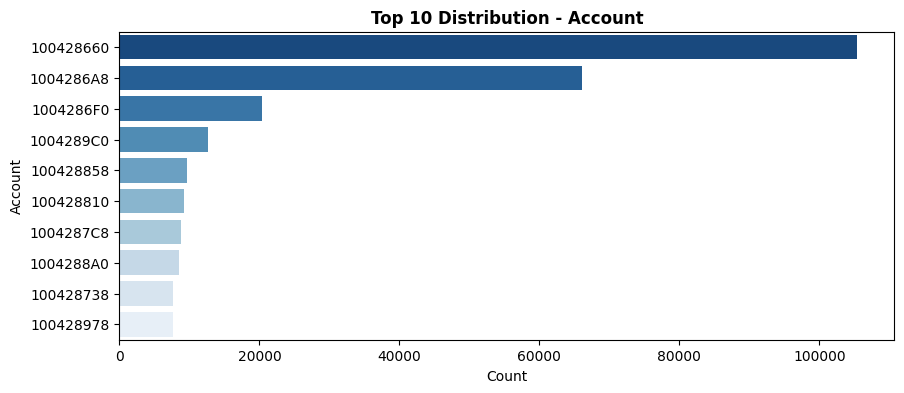

--------------------------------------------------

Top 10 Value Counts for: **Account.1**


Account.1
100428660    429
1004286A8    250
1004286F0    118
83E37F590     84
816FB88C0     84
809093660     82
850A03371     81
81B56AAE0     80
8090946A0     80
84A3553C0     78
Name: count, dtype: int64

C:\Users\almad\AppData\Local\Temp\ipykernel_32244\969024602.py:51: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


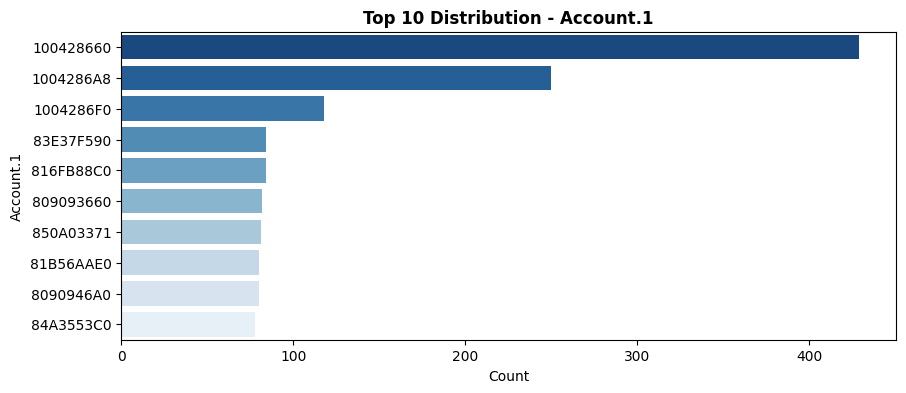

--------------------------------------------------

Top 10 Value Counts for: **Receiving Currency**


Receiving Currency
US Dollar            1828128
Euro                 1161834
Yuan                  361772
Shekel                220482
Canadian Dollar       167720
UK Pound              155936
Ruble                 154879
Australian Dollar     142721
Yen                   136352
Mexican Peso          133004
Name: count, dtype: int64

C:\Users\almad\AppData\Local\Temp\ipykernel_32244\969024602.py:51: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


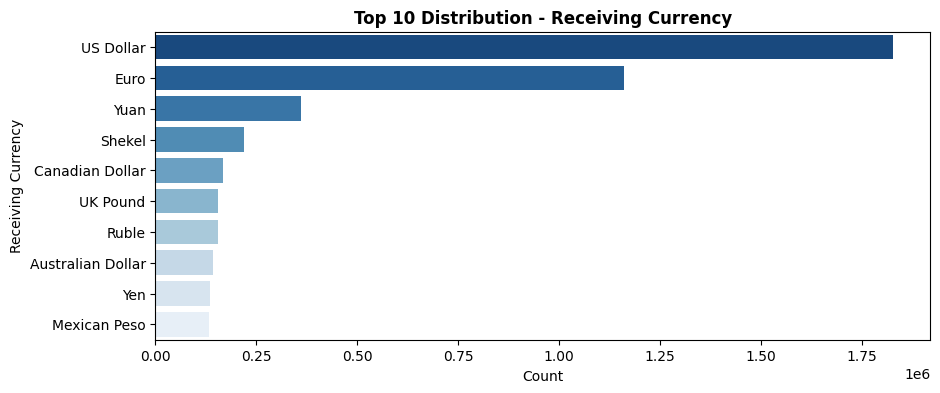

--------------------------------------------------

Top 10 Value Counts for: **Payment Currency**


Payment Currency
US Dollar            1837591
Euro                 1160330
Yuan                  365019
Shekel                218549
Canadian Dollar       166564
UK Pound              155877
Ruble                 153600
Australian Dollar     141460
Yen                   135937
Mexican Peso          131902
Name: count, dtype: int64

C:\Users\almad\AppData\Local\Temp\ipykernel_32244\969024602.py:51: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


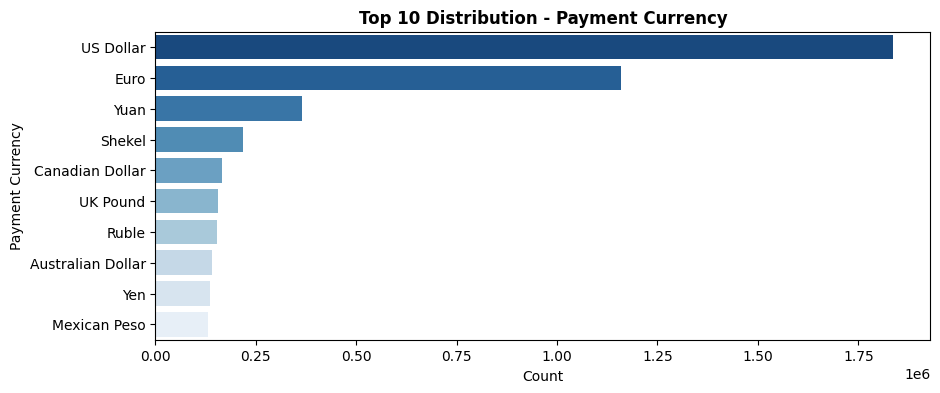

--------------------------------------------------

Top 10 Value Counts for: **Payment Format**


Payment Format
Reinvestment    1945611
Cheque          1234570
Credit Card      860723
ACH              413357
Cash             322482
Wire             120001
Bitcoin          103256
Name: count, dtype: int64

C:\Users\almad\AppData\Local\Temp\ipykernel_32244\969024602.py:51: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


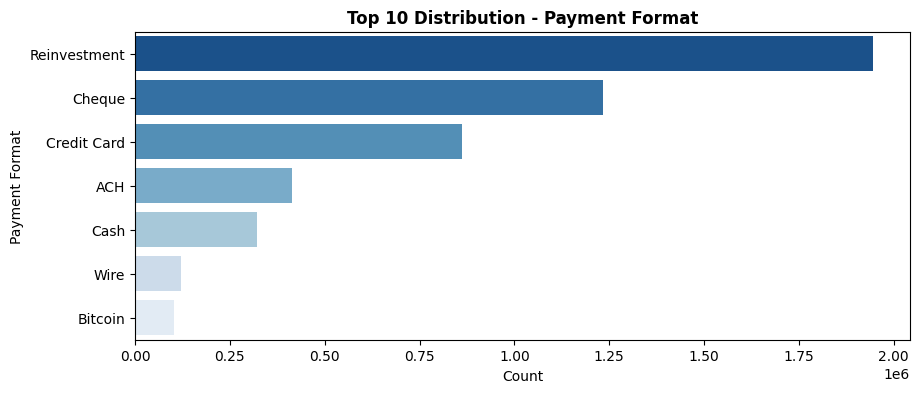

--------------------------------------------------

Top 10 Value Counts for: **Is Laundering**


Is Laundering
0    4997262
1       2738
Name: count, dtype: int64

C:\Users\almad\AppData\Local\Temp\ipykernel_32244\969024602.py:51: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


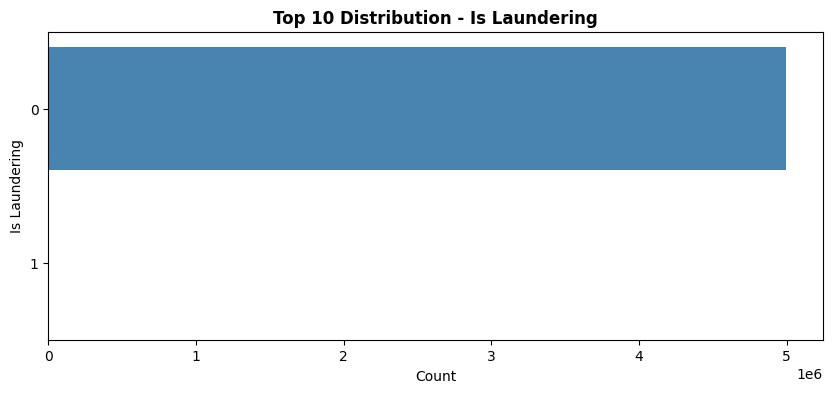

--------------------------------------------------
Inspection Report: LI-Medium Transactions
Dataset Shape: 5,000,000 rows × 11 columns


Duplicate Rows: 1
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000000 entries, 0 to 4999999
Data columns (total 11 columns):
 #   Column              Dtype  
---  ------              -----  
 0   Timestamp           object 
 1   From Bank           int64  
 2   Account             object 
 3   To Bank             int64  
 4   Account.1           object 
 5   Amount Received     float64
 6   Receiving Currency  object 
 7   Amount Paid         float64
 8   Payment Currency    object 
 9   Payment Format      object 
 10  Is Laundering       int64  
dtypes: float64(2), int64(3), object(6)
memory usage: 419.6+ MB


,Data Type,Missing Values,Missing (%),Unique Values,Sample Value
Timestamp,object,0,0.0,1936,2022/09/01 00:15
From Bank,int64,0,0.0,99178,20
Account,object,0,0.0,1702155,800104D70
To Bank,int64,0,0.0,59891,20
Account.1,object,0,0.0,1613202,800104D70
Amount Received,float64,0,0.0,2192596,8095.07
Receiving Currency,object,0,0.0,15,US Dollar
Amount Paid,float64,0,0.0,2208224,8095.07
Payment Currency,object,0,0.0,15,US Dollar
Payment Format,object,0,0.0,7,Reinvestment


=== Numerical Feature Summary ===


,From Bank,To Bank,Amount Received,Amount Paid
count,5.000000e+06,5.000000e+06,5.000000e+06,5.000000e+06
mean,3.512993e+05,4.164956e+05,1.319975e+07,9.096157e+06
std,6.802425e+05,6.847147e+05,2.854322e+09,2.076455e+09
min,0.000000e+00,0.000000e+00,1.000000e-06,1.000000e-06
25%,1.218800e+04,2.967700e+04,1.299800e+02,1.308000e+02
50%,1.147500e+05,1.462370e+05,1.926035e+03,1.929470e+03
75%,2.340050e+05,2.607610e+05,2.330899e+04,2.320744e+04
max,3.219766e+06,3.219766e+06,2.020628e+12,2.020628e+12




=== Categorical Feature Distributions ===

Top 10 Value Counts for: **Account**


Account
10042B660    111112
10042B6A8     66736
10042B6F0     15389
10042B780     11587
10042B858      9404
10042B978      9329
10042B8A0      9218
10042B810      8785
10042B738      8437
10042B930      8117
Name: count, dtype: int64

C:\Users\almad\AppData\Local\Temp\ipykernel_32244\969024602.py:51: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


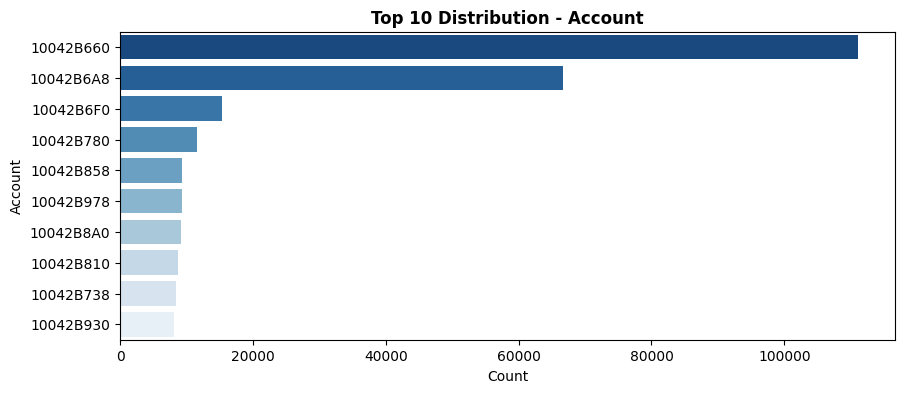

--------------------------------------------------

Top 10 Value Counts for: **Account.1**


Account.1
10042B660    512
10042B6A8    285
84955F9D0     90
844479880     88
8345F8B20     85
822DDB740     83
8009F3660     82
801C7CAB0     81
84A354780     81
8264171B0     80
Name: count, dtype: int64

C:\Users\almad\AppData\Local\Temp\ipykernel_32244\969024602.py:51: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


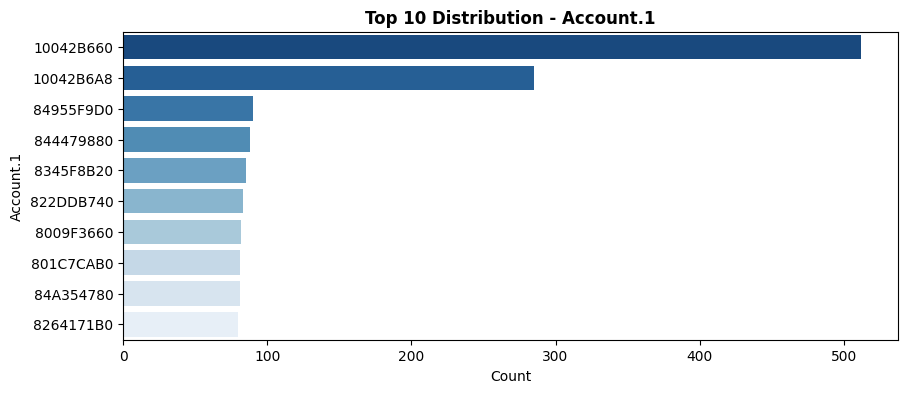

--------------------------------------------------

Top 10 Value Counts for: **Receiving Currency**


Receiving Currency
US Dollar            1895637
Euro                 1182669
Yuan                  265402
Rupee                 199661
Canadian Dollar       159827
Swiss Franc           156665
Australian Dollar     152295
UK Pound              148895
Yen                   147135
Brazil Real           139287
Name: count, dtype: int64

C:\Users\almad\AppData\Local\Temp\ipykernel_32244\969024602.py:51: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


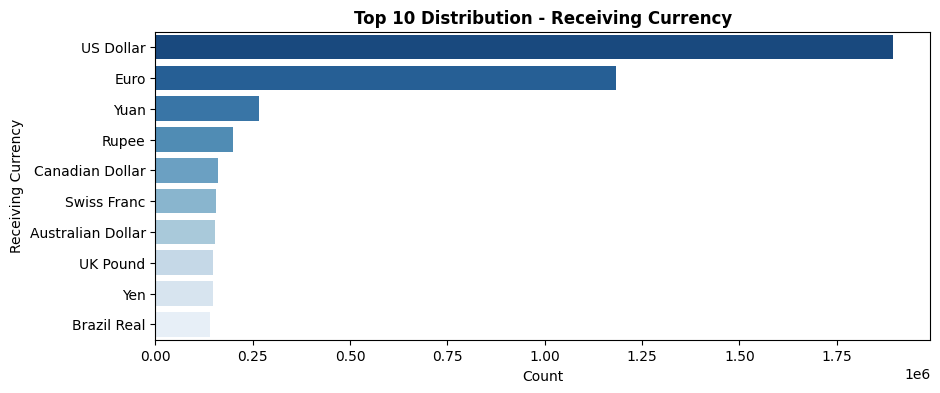

--------------------------------------------------

Top 10 Value Counts for: **Payment Currency**


Payment Currency
US Dollar            1903842
Euro                 1181646
Yuan                  270040
Rupee                 198537
Canadian Dollar       158710
Swiss Franc           155159
Australian Dollar     150883
UK Pound              148975
Yen                   146578
Brazil Real           137994
Name: count, dtype: int64

C:\Users\almad\AppData\Local\Temp\ipykernel_32244\969024602.py:51: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


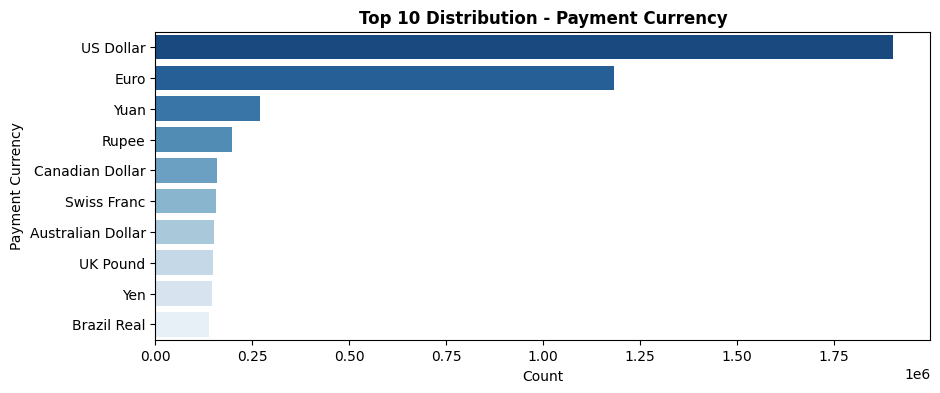

--------------------------------------------------

Top 10 Value Counts for: **Payment Format**


Payment Format
Reinvestment    1905360
Cheque          1256102
Credit Card      871600
ACH              418864
Cash             328135
Wire             122307
Bitcoin           97632
Name: count, dtype: int64

C:\Users\almad\AppData\Local\Temp\ipykernel_32244\969024602.py:51: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


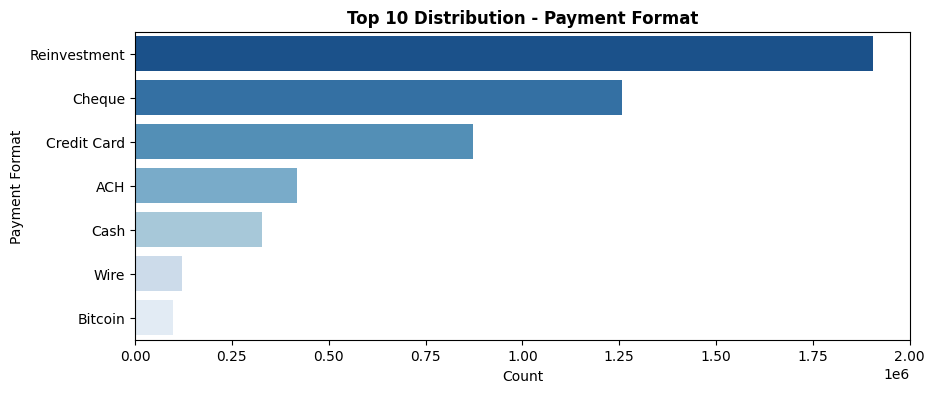

--------------------------------------------------

Top 10 Value Counts for: **Is Laundering**


Is Laundering
0    4998791
1       1209
Name: count, dtype: int64

C:\Users\almad\AppData\Local\Temp\ipykernel_32244\969024602.py:51: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


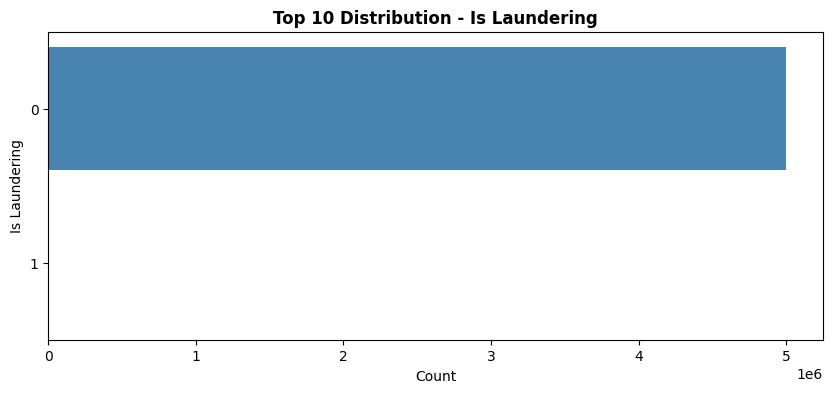

--------------------------------------------------


In [21]:
for dataset_name, trans_df in [
    ("HI-Medium Transactions", hi_medium_trans),
    ("LI-Medium Transactions", li_medium_trans),
]:
    display(inspect_dataset(trans_df, dataset_name=dataset_name))
    univariate_analysis(
        trans_df,
        categorical_cols=transaction_categorical_cols,
        numerical_cols=transaction_numerical_cols,
        datetime_cols=transaction_datetime_cols,
    )

## 4. Accounts Dataset Analysis

### 4.1 Small Accounts Dataset Exploration

In [ ]:
# Load the HI-Small and LI-Small transaction datasets.
hi_small_accounts = pd.read_csv(DATA_DIR / "HI-Small_Accounts.csv")
li_small_accounts = pd.read_csv(DATA_DIR / "LI-Small_Accounts.csv")

In [ ]:
display(inspect_dataset(hi_small_accounts, dataset_name="HI-Small Accounts"))
display(inspect_dataset(li_small_accounts, dataset_name="LI-Small Accounts"))

Inspection Report: HI-Small Accounts
Dataset Shape: 518,581 rows × 5 columns


Duplicate Rows: 0
<class 'pandas.DataFrame'>
RangeIndex: 518581 entries, 0 to 518580
Data columns (total 5 columns):
 #   Column          Non-Null Count   Dtype
---  ------          --------------   -----
 0   Bank Name       518581 non-null  str  
 1   Bank ID         518581 non-null  int64
 2   Account Number  518581 non-null  str  
 3   Entity ID       518581 non-null  str  
 4   Entity Name     518581 non-null  str  
dtypes: int64(1), str(4)
memory usage: 19.8 MB


,Data Type,Missing Values,Missing (%),Unique Values,Sample Value
Bank Name,str,0,0.0,20053,Portugal Bank #4507
Bank ID,int64,0,0.0,30470,331579
Account Number,str,0,0.0,518573,80B779D80
Entity ID,str,0,0.0,166207,80062E240
Entity Name,str,0,0.0,166207,Sole Proprietorship #50438


**Inspection summary:** HI-Small Accounts contains 518,581 rows and 5 columns, with no missing values or duplicate rows. `Account Number` and `Entity ID` are alphanumeric identifiers and correctly remain strings; converting them to integers would lose their identifier format.


In [ ]:
accounts_categorical_cols = [
    "Bank Name", 
    "Account Number",
    "Entity ID",
    "Entity Name"  # Binary target
]

accounts_numerical_cols = [
    "Bank ID"
]


=== Numerical Feature Summary ===


,Bank ID
count,518581.000000
mean,103425.510831
std,121479.549761
min,1.000000
25%,11107.000000
50%,32014.000000
75%,217096.000000
max,356303.000000




=== Categorical Feature Distributions ===

Top 10 Value Counts for: **Bank Name**


Bank Name
National Bank of Laramie       3797
National Bank of the East      3663
Japan Bank #0                  3051
Arbor Savings Bank             2894
National Bank of Pittsburgh    2683
Savings Bank of Fairfield      2642
First Bank of Tampa            2464
Savings Bank of Huron          2379
Savings Bank of Los Angeles    2052
Golden Bancorp                 1967
Name: count, dtype: int64

C:\Users\almad\AppData\Local\Temp\ipykernel_13336\3316350387.py:51: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


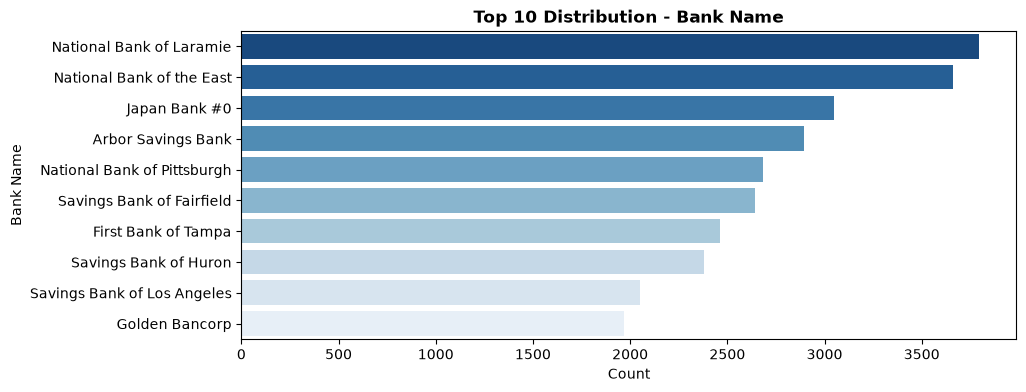

--------------------------------------------------

Top 10 Value Counts for: **Entity Name**


Entity Name
Corporation #34854            7820
Country #1                    6677
Corporation #35871            4645
Sole Proprietorship #32941    3743
Corporation #33736            3402
Partnership #32618            3309
Partnership #33830            3057
Partnership #37705            2744
Partnership #36544            2705
Partnership #38444            2511
Name: count, dtype: int64

C:\Users\almad\AppData\Local\Temp\ipykernel_13336\3316350387.py:51: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


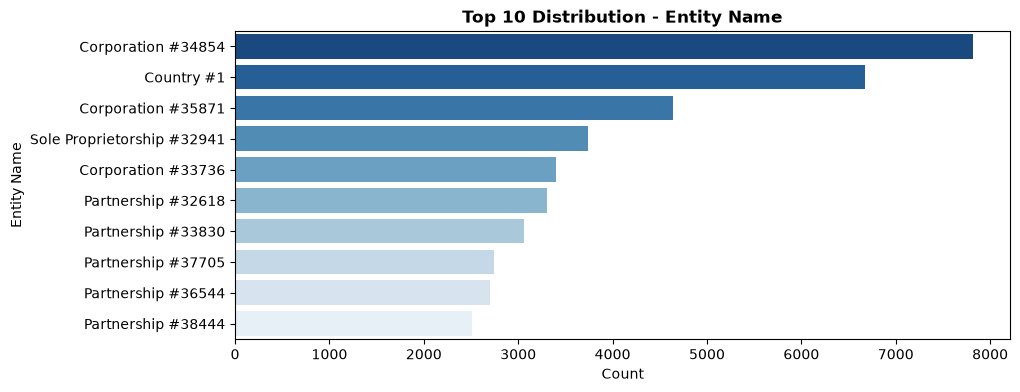

--------------------------------------------------


In [ ]:
univariate_analysis(
    hi_small_accounts,
    categorical_cols=accounts_categorical_cols,
    numerical_cols=accounts_numerical_cols,
)


**Categorical balance:** Based on category proportions, `Bank Name` and `Entity Name` are broadly spread with no dominant category (the largest shares are 0.73% and 1.51%, respectively), although the high-cardinality distributions are not perfectly uniform.


In [ ]:
# Load the HI-Medium and LI-Medium transaction datasets.
hi_medium_accounts = pd.read_csv(DATA_DIR / "HI-Medium_Accounts.csv")
li_medium_accounts = pd.read_csv(DATA_DIR / "LI-Medium_Accounts.csv")

In [ ]:
display(inspect_dataset(hi_medium_accounts, dataset_name="HI-Medium Accounts"))
display(inspect_dataset(li_medium_accounts, dataset_name="LI-Medium Accounts"))

Inspection Report: HI-Medium Accounts
Dataset Shape: 2,087,786 rows × 5 columns


Duplicate Rows: 0
<class 'pandas.DataFrame'>
RangeIndex: 2087786 entries, 0 to 2087785
Data columns (total 5 columns):
 #   Column          Dtype
---  ------          -----
 0   Bank Name       str  
 1   Bank ID         int64
 2   Account Number  str  
 3   Entity ID       str  
 4   Entity Name     str  
dtypes: int64(1), str(4)
memory usage: 79.6 MB


,Data Type,Missing Values,Missing (%),Unique Values,Sample Value
Bank Name,str,0,0.0,80180,China Bank #561
Bank ID,int64,0,0.0,122333,53267
Account Number,str,0,0.0,2087762,817D00980
Entity ID,str,0,0.0,668138,2AA1F24F180
Entity Name,str,0,0.0,668138,Corporation #183669


**Inspection summary:** HI-Medium Accounts contains 2,087,786 rows and 5 columns, with no missing values or duplicate rows. `Account Number` and `Entity ID` are alphanumeric identifiers and correctly remain strings; converting them to integers would lose their identifier format.


=== Numerical Feature Summary ===


,Bank ID
count,2.087786e+06
mean,6.321024e+05
std,9.703746e+05
min,0.000000e+00
25%,3.962400e+04
50%,2.037290e+05
75%,3.812120e+05
max,3.225455e+06




=== Categorical Feature Distributions ===

Top 10 Value Counts for: **Bank Name**


Bank Name
Savings Bank of Indianapolis    5635
Savings Bank of Seattle         5575
First Bank of Plattsburg        4983
First Bank of Miami             4887
Bank of Miami                   4722
National Bank of Plattsburg     4610
National Bank of New Orleans    4557
Bank of Huron                   4542
Savings Bank of Newbury         4416
National Bank of Los Angeles    4264
Name: count, dtype: int64

C:\Users\almad\AppData\Local\Temp\ipykernel_13336\3316350387.py:51: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


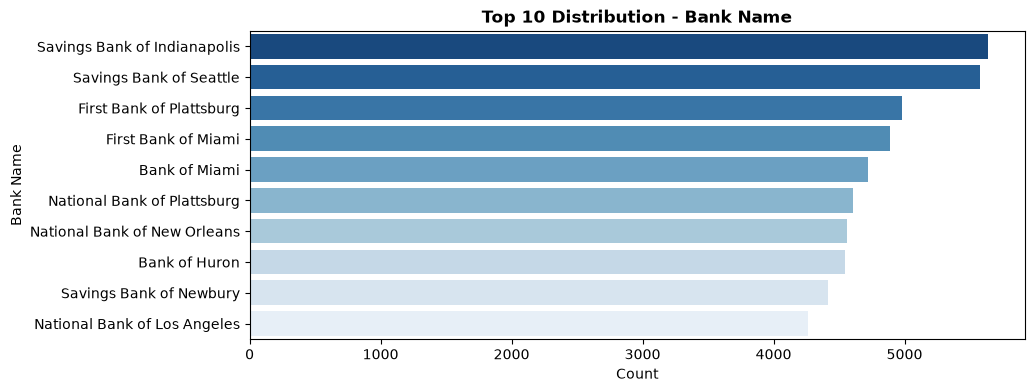

--------------------------------------------------

Top 10 Value Counts for: **Entity Name**


Entity Name
Corporation #140481            8638
Partnership #139664            5639
Country #1                     4738
Partnership #130756            4714
Sole Proprietorship #145836    4369
Corporation #132573            4237
Sole Proprietorship #144757    4078
Partnership #133653            4058
Corporation #139355            3666
Corporation #140482            3290
Name: count, dtype: int64

C:\Users\almad\AppData\Local\Temp\ipykernel_13336\3316350387.py:51: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


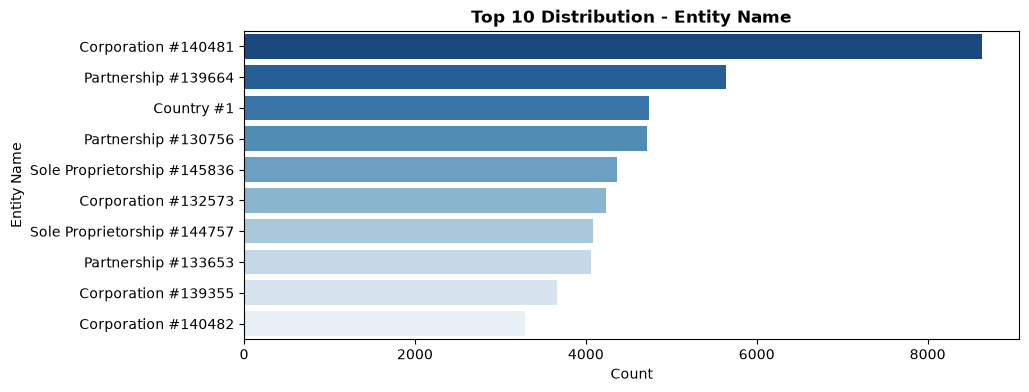

--------------------------------------------------


In [ ]:
univariate_analysis(
    hi_medium_accounts,
    categorical_cols=accounts_categorical_cols,
    numerical_cols=accounts_numerical_cols,
)


**Categorical balance:** Based on category proportions, `Bank Name` and `Entity Name` are broadly spread with no dominant category (largest shares: 0.27% and 0.41%). The distributions are high-cardinality and not perfectly uniform.


#### 3.4.2 Future Steps

**Preprocessing:** Use the transaction data as the central dataset: each row represents a transfer, and `Is Laundering` is its target label. Link sender details using `From Bank` and `Account`, and receiver details using `To Bank` and `Account.1`; match these to `Bank ID` and `Account Number` in the account data. Keep identifiers as strings, standardize their formatting, and retain the dataset `Type` to prevent accidental cross-source matches. Add sender and receiver metadata separately. `Entity ID` can group accounts belonging to one entity, but should not be used alone as the account join key. Use pattern files to understand suspicious sequences (such as cycles, fan-in, and fan-out), but do not simply append their rows to the transaction data: patterns contain laundering examples only, which would distort class balance. Avoid using pattern-derived labels as input features when they reveal the target, to prevent target leakage.

**Feature engineering:** After linking the account metadata, derive transaction and account activity features, including amounts and currencies, the difference between amounts paid and received, sender and receiver transaction counts and totals over time windows, numbers of distinct counterparties, how quickly funds move onward, unusually high inbound or outbound activity, and whether transactions form cycles or resemble fan-in/fan-out. These features add behavioral context beyond an individual transfer and can then be used by a model or rules-based detector.


### 4. Transaction Volume Velocity Over Time

Inspecting transaction timestamps to detect hourly, daily, and velocity patterns.

In [ ]:
print(hi_small_trans['Timestamp'].min(), hi_small_trans['Timestamp'].max()) 
print(li_small_trans['Timestamp'].min(), hi_small_trans['Timestamp'].max())

2022/09/01 00:00 2022/09/01 00:29
2022/09/01 00:00 2022/09/01 00:29


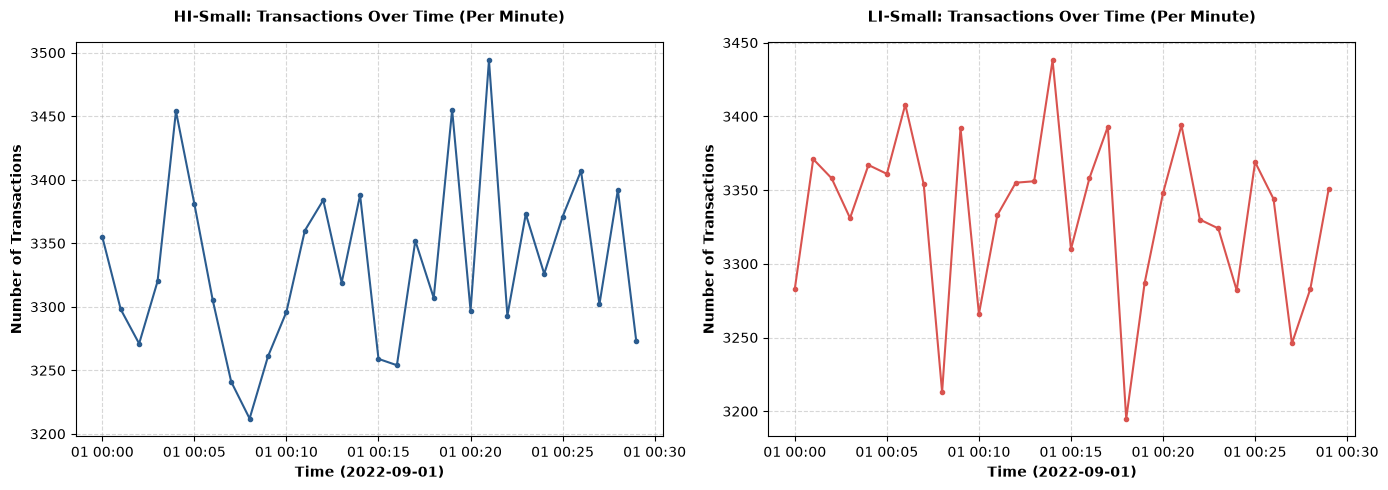

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

# Garantir que a coluna Timestamp está em formato datetime
hi_small_trans['Timestamp'] = pd.to_datetime(hi_small_trans['Timestamp'])
li_small_trans['Timestamp'] = pd.to_datetime(li_small_trans['Timestamp'])

# Agrupar por minuto ('min') para ver a evolução nos 30 minutos da amostra
hi_minutely = hi_small_trans.set_index('Timestamp').resample('min').size()
li_minutely = li_small_trans.set_index('Timestamp').resample('min').size()

# Criar a figura com dois subgráficos lado a lado
fig, ax = plt.subplots(1, 2, figsize=(14, 5))

# --- Gráfico 1: HI-Small ---
ax[0].plot(hi_minutely.index, hi_minutely.values, color='#2b5c8f', linewidth=1.5, marker='o', markersize=3)
ax[0].set_title('HI-Small: Transactions Over Time (Per Minute)', fontsize=11, fontweight='bold', pad=15)
ax[0].set_xlabel('Time (2022-09-01)', fontsize=10, fontweight='bold')
ax[0].set_ylabel('Number of Transactions', fontsize=10, fontweight='bold')
ax[0].grid(True, linestyle='--', alpha=0.5)

# --- Gráfico 2: LI-Small ---
ax[1].plot(li_minutely.index, li_minutely.values, color='#d9534f', linewidth=1.5, marker='o', markersize=3)
ax[1].set_title('LI-Small: Transactions Over Time (Per Minute)', fontsize=11, fontweight='bold', pad=15)
ax[1].set_xlabel('Time (2022-09-01)', fontsize=10, fontweight='bold')
ax[1].set_ylabel('Number of Transactions', fontsize=10, fontweight='bold')
ax[1].grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

##### Transaction Volume Velocity Over Time Insights

The transaction volume remains relatively stable throughout the 30 minutes analyzed, consistently fluctuating within a predictable range of 3,200 to 3,500 transactions per minute. There are no abrupt interruptions or extreme traffic spikes, indicating a continuous and uniform flow within the data sample. Furthermore, both datasets (HI-Small and LI-Small) exhibit very similar pacing behavior.


### 5. Payment Channel Analysis 

Evaluating volume and risk distribution across payment formats (Wire, ACH, Cheque, Credit Card, Reinvestment, etc.).

,Total_Transactions,Laundering_Count,Laundering_Rate_Pct
Payment Format,,,
Cash,2668,1,0.0375
Credit Card,9028,2,0.0222
Cheque,9393,2,0.0213
Bitcoin,30,0,0.0000
ACH,4436,0,0.0000
Reinvestment,73296,0,0.0000
Wire,1149,0,0.0000


C:\Users\almad\AppData\Local\Temp\ipykernel_13336\374739332.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=format_stats.index, y=format_stats['Total_Transactions'], ax=ax[0], palette='Blues_r')
C:\Users\almad\AppData\Local\Temp\ipykernel_13336\374739332.py:15: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  ax[0].set_xticklabels(ax[0].get_xticklabels(), rotation=45)
C:\Users\almad\AppData\Local\Temp\ipykernel_13336\374739332.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=format_stats.index, y=format_stats['Laundering_Rate_Pct'], ax=ax[1], palette='Reds_r')
C

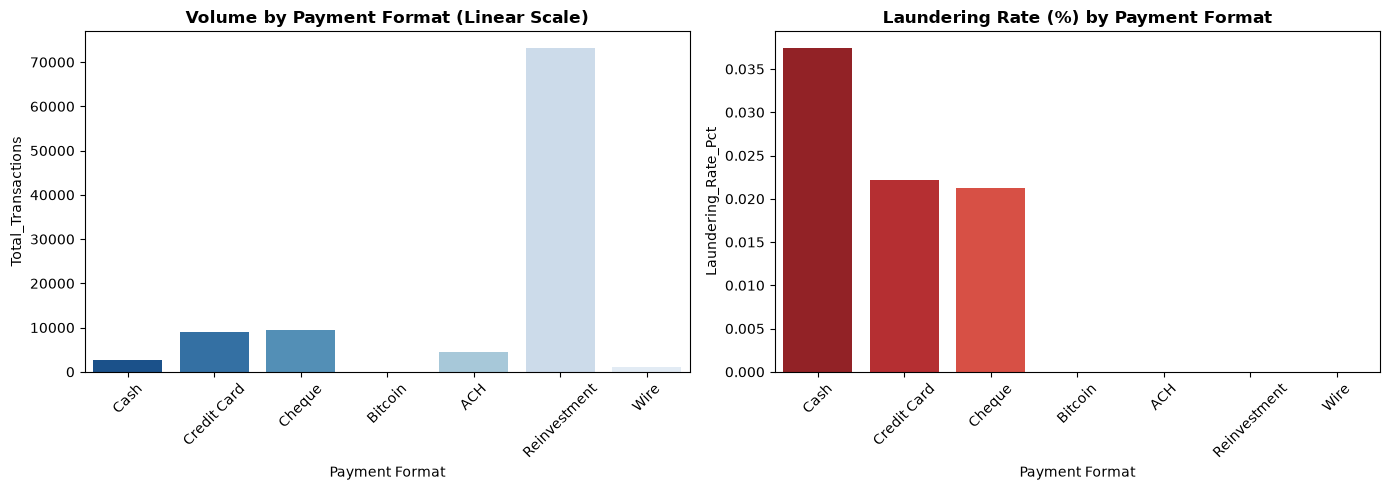

In [ ]:
# Read-only format risk summary
format_stats = hi_small_trans.groupby('Payment Format').agg(
    Total_Transactions=('Is Laundering', 'count'),
    Laundering_Count=('Is Laundering', 'sum'),
    Laundering_Rate_Pct=('Is Laundering', lambda x: (x.sum() / len(x)) * 100)
).sort_values(by='Laundering_Rate_Pct', ascending=False)

display(format_stats.round(4))

fig, ax = plt.subplots(1, 2, figsize=(14, 5))

# Total Volume by Payment Format (Escala linear, sem transformações)
sns.barplot(x=format_stats.index, y=format_stats['Total_Transactions'], ax=ax[0], palette='Blues_r')
ax[0].set_title('Volume by Payment Format (Linear Scale)', fontsize=12, fontweight='bold')
ax[0].set_xticklabels(ax[0].get_xticklabels(), rotation=45)

# Laundering Rate by Payment Format
sns.barplot(x=format_stats.index, y=format_stats['Laundering_Rate_Pct'], ax=ax[1], palette='Reds_r')
ax[1].set_title('Laundering Rate (%) by Payment Format', fontsize=12, fontweight='bold')
ax[1].set_xticklabels(ax[1].get_xticklabels(), rotation=45)

plt.tight_layout()
plt.show()

#### Payment Channel Analysis Insights

In the first 100,000 HI-Small transaction rows, there are 5 laundering transactions. Cash has the highest observed laundering rate (0.0375%); Credit Card and Cheque each have 2 flagged transactions. No flagged rows appear for ACH, Bitcoin, Reinvestment, or Wire in this sample. These sample results should not be interpreted as full-dataset rates.


### 6. Inter-Bank vs. Intra-Bank Laundering Distribution Analysis

Inspecting inter and intra-bank relationships.

In [ ]:
# Compare laundering counts for same-bank and cross-bank transactions in the loaded sample.
interbank_table = (
    hi_small_trans.assign(
        Relationship=np.where(
            hi_small_trans["From Bank"].eq(hi_small_trans["To Bank"]),
            "Intra-Bank (Same Bank)",
            "Inter-Bank (Different Banks)",
        )
    )
    .groupby("Relationship")["Is Laundering"]
    .agg(Total="size", Laundering="sum")
)

total_laundering_cases = interbank_table["Laundering"].sum()
interbank_table["Laundering(%)"] = (
    interbank_table["Laundering"] / total_laundering_cases * 100
    if total_laundering_cases
    else 0
)

display(interbank_table[["Total", "Laundering", "Laundering(%)"]].round(4))


,Total,Laundering,Laundering(%)
Relationship,,,
Inter-Bank (Different Banks),26207,5,100.0
Intra-Bank (Same Bank),73793,0,0.0


In the first 100,000 HI-Small transaction rows, all 5 flagged laundering transactions are inter-bank; none are intra-bank. The sample contains 26,207 inter-bank and 73,793 intra-bank transactions. This describes the loaded sample only, not the full dataset.


### 7. Dataset Consolidation

Combine datasets of the same kind and retain their source in a `Type` column. Account and pattern inputs below are complete datasets; transaction dataframes contain the first 100,000 rows from each source, so `transactions_all` is a combined sample rather than the full transaction data.


#### 7.1 Combined Accounts Dataset


In [ ]:
accounts_all = pd.concat(
    [
        hi_small_accounts.assign(Type="hi_small"),
        li_small_accounts.assign(Type="li_small"),
        hi_medium_accounts.assign(Type="hi_medium"),
        li_medium_accounts.assign(Type="li_medium"),
    ],
    ignore_index=True,
)

print(f"Combined accounts shape: {accounts_all.shape}")
display(accounts_all.head())


Combined accounts shape: (5359878, 6)


,Bank Name,Bank ID,Account Number,Entity ID,Entity Name,Type
0,Portugal Bank #4507,331579,80B779D80,80062E240,Sole Proprietorship #50438,hi_small
1,Canada Bank #27,210,809D86900,800C998A0,Corporation #33520,hi_small
2,UK Bank #33,21884,80812BE00,800C47F50,Partnership #35397,hi_small
3,Germany Bank #4815,32742,81047F300,80096F0B0,Corporation #48813,hi_small
4,National Bank of Harrisburg,127390,80BD8CF00,800FB8760,Corporation #889,hi_small


In [ ]:
# Accounts have no Is Laundering target; show the row balance by source dataset.
account_source_balance = accounts_all["Type"].value_counts().sort_index().rename("Count").to_frame()
account_source_balance["Percentage"] = (account_source_balance["Count"] / len(accounts_all) * 100).round(2)
display(account_source_balance)


,Count,Percentage
Type,,
hi_medium,2087786,38.95
hi_small,518581,9.68
li_medium,2040823,38.08
li_small,712688,13.30


**Interpretation:** The account data has no `Is Laundering` label, so these percentages describe the source mix rather than a target-class balance. The two medium sources contribute about 77% of the 5.36 million accounts combined, while the two small sources contribute about 23%; the combined account table is therefore weighted toward medium-source records.

In [ ]:
account_source_class_counts = transactions_all["Is Laundering"].value_counts(dropna=False).sort_index()
transaction_class_balance = pd.DataFrame({
    "Count": account_source_class_counts,
    "Percentage": (account_source_class_counts / len(transactions_all) * 100).round(4),
})
display(transaction_class_balance)

display(pd.crosstab(
    transactions_all["Type"],
    transactions_all["Is Laundering"],
    margins=True,
    margins_name="Total",
))


,Count,Percentage
Is Laundering,,
0,399988,99.997
1,12,0.003


Is Laundering,0,1,Total
Type,,,
hi_medium,99999,1,100000
hi_small,99995,5,100000
li_medium,99997,3,100000
li_small,99997,3,100000
Total,399988,12,400000


#### 7.2 Combined Transactions Dataset


In [ ]:
transactions_all = pd.concat(
    [
        hi_small_trans.assign(Type="hi_small"),
        li_small_trans.assign(Type="li_small"),
        hi_medium_trans.assign(Type="hi_medium"),
        li_medium_trans.assign(Type="li_medium"),
    ],
    ignore_index=True,
)

print(f"Combined transaction sample shape: {transactions_all.shape}")
display(transactions_all.head())


Combined transaction sample shape: (400000, 12)


,Timestamp,From Bank,Account,To Bank,Account.1,Amount Received,Receiving Currency,Amount Paid,Payment Currency,Payment Format,Is Laundering,Type
0,2022-09-01 00:20:00,10,8000EBD30,10,8000EBD30,3697.34,US Dollar,3697.34,US Dollar,Reinvestment,0,hi_small
1,2022-09-01 00:20:00,3208,8000F4580,1,8000F5340,0.01,US Dollar,0.01,US Dollar,Cheque,0,hi_small
2,2022-09-01 00:00:00,3209,8000F4670,3209,8000F4670,14675.57,US Dollar,14675.57,US Dollar,Reinvestment,0,hi_small
3,2022-09-01 00:02:00,12,8000F5030,12,8000F5030,2806.97,US Dollar,2806.97,US Dollar,Reinvestment,0,hi_small
4,2022-09-01 00:06:00,10,8000F5200,10,8000F5200,36682.97,US Dollar,36682.97,US Dollar,Reinvestment,0,hi_small


In [ ]:
transaction_class_counts = transactions_all["Is Laundering"].value_counts(dropna=False).sort_index()
transaction_class_balance = pd.DataFrame({
    "Count": transaction_class_counts,
    "Percentage": (transaction_class_counts / len(transactions_all) * 100).round(4),
})
display(transaction_class_balance)

display(pd.crosstab(
    transactions_all["Type"],
    transactions_all["Is Laundering"],
    margins=True,
    margins_name="Total",
))


,Count,Percentage
Is Laundering,,
0,399988,99.997
1,12,0.003


Is Laundering,0,1,Total
Type,,,
hi_medium,99999,1,100000
hi_small,99995,5,100000
li_medium,99997,3,100000
li_small,99997,3,100000
Total,399988,12,400000


**Interpretation:** The combined transaction sample is severely imbalanced: only 12 of 400,000 rows (0.003%) are labeled laundering, compared with 399,988 non-laundering rows (99.997%). Each source contributes 100,000 sampled rows, with between 1 and 5 positive examples per source. A model that predicts only the majority class could appear highly accurate while missing the laundering cases, so accuracy alone would be misleading. These proportions describe the loaded samples, not the full transaction files.

#### 7.3 Combined Patterns Dataset


In [ ]:
patterns_all = pd.concat(
    [
        hi_small_patterns.assign(Type="hi_small"),
        li_small_patterns.assign(Type="li_small"),
        hi_medium_patterns.assign(Type="hi_medium"),
        li_medium_patterns.assign(Type="li_medium"),
    ],
    ignore_index=True,
)

print(f"Combined patterns shape: {patterns_all.shape}")
display(patterns_all.head())


Combined patterns shape: (30884, 13)


,Timestamp,From Bank,From Account,To Bank,To Account,Amount Received,Receiving Currency,Amount Paid,Payment Currency,Payment Format,Is Laundering,Pattern Type,Type
0,2022/09/01 00:06,021174,800737690,012,80011F990,2848.96,Euro,2848.96,Euro,ACH,1,FAN-OUT,hi_small
1,2022/09/01 04:33,021174,800737690,020,80020C5B0,8630.40,Euro,8630.40,Euro,ACH,1,FAN-OUT,hi_small
2,2022/09/01 09:14,021174,800737690,020,80006A5E0,35642.49,Yuan,35642.49,Yuan,ACH,1,FAN-OUT,hi_small
3,2022/09/01 09:56,021174,800737690,00220,8007A5B70,5738987.96,US Dollar,5738987.96,US Dollar,ACH,1,FAN-OUT,hi_small
4,2022/09/01 11:28,021174,800737690,001244,80093C0D0,7254.53,US Dollar,7254.53,US Dollar,ACH,1,FAN-OUT,hi_small


In [ ]:
pattern_class_counts = patterns_all["Is Laundering"].value_counts(dropna=False).sort_index()
pattern_class_balance = pd.DataFrame({
    "Count": pattern_class_counts,
    "Percentage": (pattern_class_counts / len(patterns_all) * 100).round(4),
})
display(pattern_class_balance)

display(patterns_all["Pattern Type"].value_counts(dropna=False).rename("Count").to_frame())
display(pd.crosstab(
    patterns_all["Type"],
    patterns_all["Is Laundering"],
    margins=True,
    margins_name="Total",
))


,Count,Percentage
Is Laundering,,
1,30884,100.0


,Count
Pattern Type,
GATHER-SCATTER,5696
SCATTER-GATHER,5682
STACK,5247
FAN-OUT,3108
FAN-IN,3035
BIPARTITE,3015
CYCLE,2888
RANDOM,2213


Is Laundering,1,Total
Type,,
hi_medium,22743,22743
hi_small,3209,3209
li_medium,3909,3909
li_small,1023,1023
Total,30884,30884


**Interpretation:** All 30,884 rows in the patterns dataset are labeled laundering. This is expected for a dataset of identified laundering patterns, but it does not represent the natural class balance of all transactions and cannot by itself provide both classes for binary classification. The pattern-type counts describe the mix of detected patterns, not the laundering-versus-legitimate balance.

#### 7.4 Link Accounts to Transactions and Check Class Balance

Join sender and receiver account metadata separately. Match senders on `Type`, `From Bank`, and `Account`; match receivers on `Type`, `To Bank`, and `Account.1`. These correspond to `Type`, `Bank ID`, and `Account Number` in `accounts_all`. Keys are standardized as trimmed strings for matching, while the original transaction columns remain unchanged. The left joins preserve every transaction row; unmatched account details remain missing and are counted below. The final linked transaction dataset is named `data`; the class balance and plot below summarize all rows currently loaded, which are 100,000 transaction samples per source.


In [ ]:
# Preserve the combined transaction rows and prepare normalized string keys.
transactions_with_accounts = transactions_all.copy()
transactions_with_accounts["_type_key"] = transactions_with_accounts["Type"].astype("string").str.strip()
transactions_with_accounts["_sender_bank_key"] = transactions_with_accounts["From Bank"].astype("string").str.strip()
transactions_with_accounts["_sender_account_key"] = transactions_with_accounts["Account"].astype("string").str.strip()
transactions_with_accounts["_receiver_bank_key"] = transactions_with_accounts["To Bank"].astype("string").str.strip()
transactions_with_accounts["_receiver_account_key"] = transactions_with_accounts["Account.1"].astype("string").str.strip()

# Restrict joins to each source dataset and use the bank/account pair as the key.
account_lookup = accounts_all[
    ["Type", "Bank ID", "Account Number", "Bank Name", "Entity ID", "Entity Name"]
].copy()
account_lookup["_type_key"] = account_lookup["Type"].astype("string").str.strip()
account_lookup["_bank_key"] = account_lookup["Bank ID"].astype("string").str.strip()
account_lookup["_account_key"] = account_lookup["Account Number"].astype("string").str.strip()

sender_lookup = account_lookup[
    ["_type_key", "_bank_key", "_account_key", "Bank Name", "Entity ID", "Entity Name"]
].rename(columns={
    "_bank_key": "_sender_bank_key",
    "_account_key": "_sender_account_key",
    "Bank Name": "Sender Bank Name",
    "Entity ID": "Sender Entity ID",
    "Entity Name": "Sender Entity Name",
})
receiver_lookup = account_lookup[
    ["_type_key", "_bank_key", "_account_key", "Bank Name", "Entity ID", "Entity Name"]
].rename(columns={
    "_bank_key": "_receiver_bank_key",
    "_account_key": "_receiver_account_key",
    "Bank Name": "Receiver Bank Name",
    "Entity ID": "Receiver Entity ID",
    "Entity Name": "Receiver Entity Name",
})

original_row_count = len(transactions_all)
original_rows_by_type = transactions_all.groupby("Type", observed=True).size().sort_index()

transactions_with_accounts = transactions_with_accounts.merge(
    sender_lookup,
    left_on=["_type_key", "_sender_bank_key", "_sender_account_key"],
    right_on=["_type_key", "_sender_bank_key", "_sender_account_key"],
    how="left",
    validate="many_to_one",
    indicator="_sender_merge",
)
transactions_with_accounts["Sender Account Matched"] = transactions_with_accounts["_sender_merge"].eq("both")
transactions_with_accounts = transactions_with_accounts.drop(columns="_sender_merge")

transactions_with_accounts = transactions_with_accounts.merge(
    receiver_lookup,
    left_on=["_type_key", "_receiver_bank_key", "_receiver_account_key"],
    right_on=["_type_key", "_receiver_bank_key", "_receiver_account_key"],
    how="left",
    validate="many_to_one",
    indicator="_receiver_merge",
)
transactions_with_accounts["Receiver Account Matched"] = transactions_with_accounts["_receiver_merge"].eq("both")
transactions_with_accounts = transactions_with_accounts.drop(
    columns=["_receiver_merge", "_type_key", "_sender_bank_key", "_sender_account_key", "_receiver_bank_key", "_receiver_account_key"]
)

if len(transactions_with_accounts) != original_row_count:
    raise AssertionError(
        f"Account joins changed the transaction row count: {original_row_count} -> {len(transactions_with_accounts)}"
    )

rows_by_type_after = transactions_with_accounts.groupby("Type", observed=True).size().sort_index()
if not original_rows_by_type.equals(rows_by_type_after):
    raise AssertionError("Account joins changed the transaction row count for at least one source Type")

sender_missing = int((~transactions_with_accounts["Sender Account Matched"]).sum())
receiver_missing = int((~transactions_with_accounts["Receiver Account Matched"]).sum())
print(f"Transaction rows before joins: {original_row_count:,}")
print(f"Transaction rows after joins:  {len(transactions_with_accounts):,}")
print(f"Rows preserved by Type: {original_rows_by_type.to_dict() == rows_by_type_after.to_dict()}")
print(f"Sender accounts without a match: {sender_missing:,}")
print(f"Receiver accounts without a match: {receiver_missing:,}")
print("Missing joined sender metadata:")
display(transactions_with_accounts[["Sender Bank Name", "Sender Entity ID", "Sender Entity Name"]].isna().sum().rename("Missing values"))
print("Missing joined receiver metadata:")
display(transactions_with_accounts[["Receiver Bank Name", "Receiver Entity ID", "Receiver Entity Name"]].isna().sum().rename("Missing values"))
display(transactions_with_accounts.head())


Transaction rows before joins: 400,000
Transaction rows after joins:  400,000
Rows preserved by Type: True
Sender accounts without a match: 0
Receiver accounts without a match: 0
Missing joined sender metadata:


Sender Bank Name      0
Sender Entity ID      0
Sender Entity Name    0
Name: Missing values, dtype: int64

Missing joined receiver metadata:


Receiver Bank Name      0
Receiver Entity ID      0
Receiver Entity Name    0
Name: Missing values, dtype: int64

,Timestamp,From Bank,Account,To Bank,Account.1,Amount Received,Receiving Currency,Amount Paid,Payment Currency,Payment Format,Is Laundering,Type,Sender Bank Name,Sender Entity ID,Sender Entity Name,Sender Account Matched,Receiver Bank Name,Receiver Entity ID,Receiver Entity Name,Receiver Account Matched
0,2022-09-01 00:20:00,10,8000EBD30,10,8000EBD30,3697.34,US Dollar,3697.34,US Dollar,Reinvestment,0,hi_small,National Bank of Laramie,800D232D0,Partnership #1,True,National Bank of Laramie,800D232D0,Partnership #1,True
1,2022-09-01 00:20:00,3208,8000F4580,1,8000F5340,0.01,US Dollar,0.01,US Dollar,Cheque,0,hi_small,Sappo Cooperative Bank,8008EEA70,Partnership #2,True,Arbor Savings Bank,800AA5D20,Corporation #1,True
2,2022-09-01 00:00:00,3209,8000F4670,3209,8000F4670,14675.57,US Dollar,14675.57,US Dollar,Reinvestment,0,hi_small,National Bank of Fort Wayne,800FBB3A0,Partnership #3,True,National Bank of Fort Wayne,800FBB3A0,Partnership #3,True
3,2022-09-01 00:02:00,12,8000F5030,12,8000F5030,2806.97,US Dollar,2806.97,US Dollar,Reinvestment,0,hi_small,National Bank of the East,800C0EF20,Sole Proprietorship #1,True,National Bank of the East,800C0EF20,Sole Proprietorship #1,True
4,2022-09-01 00:06:00,10,8000F5200,10,8000F5200,36682.97,US Dollar,36682.97,US Dollar,Reinvestment,0,hi_small,National Bank of Laramie,800C3EC10,Partnership #4,True,National Bank of Laramie,800C3EC10,Partnership #4,True


,Count,Percentage
Is Laundering,,
0,399988,99.997
1,12,0.003


Is Laundering,0,1,Total
Type,,,
hi_medium,99999,1,100000
hi_small,99995,5,100000
li_medium,99997,3,100000
li_small,99997,3,100000
Total,399988,12,400000


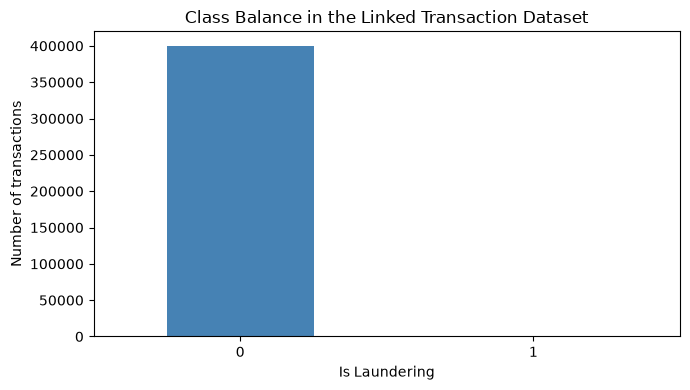

In [ ]:
data = transactions_with_accounts.copy()

class_counts = data["Is Laundering"].value_counts(dropna=False).sort_index()
class_balance = pd.DataFrame({
    "Count": class_counts,
    "Percentage": (class_counts / len(data) * 100).round(4),
})
display(class_balance)

display(pd.crosstab(
    data["Type"],
    data["Is Laundering"],
    margins=True,
    margins_name="Total",
))

ax = class_counts.plot(kind="bar", figsize=(7, 4), color="steelblue")
ax.set_title("Class Balance in the Linked Transaction Dataset")
ax.set_xlabel("Is Laundering")
ax.set_ylabel("Number of transactions")
ax.tick_params(axis="x", rotation=0)
plt.tight_layout()
plt.show()


**Interpretation:** The join preserved all 400,000 transaction rows, and every sender and receiver account matched. The linked dataset therefore has the same class balance as the transaction sample in 7.2: 399,988 non-laundering rows (99.997%) and 12 laundering rows (0.003%). Linking account metadata did not add or remove examples or change the target labels. The class remains severely imbalanced, and these results apply to the loaded samples rather than the full transaction files.

### 8. Save Final Dataset

Save the final linked transaction sample as `data/transactions_data.csv` for reuse. The exported file contains the currently loaded sample (100,000 transaction rows per source), not the complete transaction files.

In [ ]:
transactions_data = data.copy()
transactions_data_path = os.path.join("data", "transactions_data.csv")
transactions_data.to_csv(transactions_data_path, index=False)

print(f"Saved {len(transactions_data):,} rows to {transactions_data_path}")